In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL & IMPORT                               ║
# ╚══════════════════════════════════════════════════════════╝

!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — LOAD DATASET                                  ║
# ╚══════════════════════════════════════════════════════════╝


df = pd.read_csv("/content/CBC_data_with_Diagnosis.csv")


print("\nDataset Loaded Successfully\n")
print(df.head())
print("\nShape:", df.shape)
print("\nDiagnosis Distribution:\n", df['Diagnosis'].value_counts())



Dataset Loaded Successfully

   PATIENT ID  GENDER  HAEMOGLOBIN   TLC  POLYMORPH  LYMPHOCYTES  EOSINOPHILS  \
0           1  FEMALE         10.0  7000       59.0           12           28   
1           2    MALE         13.0  7400       65.0           24           10   
2           3    MALE         14.9  3600       72.0           16           11   
3           4    MALE         14.2  7900       67.0           18           14   
4           5  FEMALE         12.1  3300       56.0           34            9   

   MONOCYTES  BASOPHILS   RBC  ...  H.C.T  M.C.V  M.C.H  M.C.H.C  \
0        1.0          0  4.37  ...   34.5   78.9   22.9     29.0   
1        1.0          0  4.70  ...   41.8   88.9   27.7     31.0   
2        1.0          0  5.94  ...   51.1   85.7   25.0     29.0   
3        1.0          0  4.82  ...   47.3   98.1   29.5     30.0   
4        1.0          0  5.00  ...   41.2   82.4   24.2     29.0   

   PLATELET COUNT.1    TLC.1 H.C.T.1      Hb.       NS1         Diagnosis 

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — HANDLE MISSING VALUES                         ║
# ╚══════════════════════════════════════════════════════════╝

numeric_columns = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='mean')
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

print("Missing values handled.")

Missing values handled.


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — FEATURES & TARGET                             ║
# ║
# ╚══════════════════════════════════════════════════════════╝

X = df.drop('Diagnosis', axis=1)

# Drop ID, leakage, and duplicate columns
X = X.drop([
    'PATIENT ID',
    'NS1',
    'PLATELET COUNT.1',
    'TLC.1',
    'H.C.T.1',
    'Hb.',
], axis=1)

y = df['Diagnosis']

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — ENCODE FEATURES                               ║
# ╚══════════════════════════════════════════════════════════╝

categorical_cols = X.select_dtypes(include='object').columns

gender_encoder = LabelEncoder()
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded Features:\n")
print(X.head())
print("\nClasses:", label_encoder.classes_)


Encoded Features:

   GENDER  HAEMOGLOBIN     TLC  POLYMORPH  LYMPHOCYTES  EOSINOPHILS  \
0       0         10.0  7000.0       59.0         12.0         28.0   
1       2         13.0  7400.0       65.0         24.0         10.0   
2       2         14.9  3600.0       72.0         16.0         11.0   
3       2         14.2  7900.0       67.0         18.0         14.0   
4       0         12.1  3300.0       56.0         34.0          9.0   

   MONOCYTES  BASOPHILS   RBC  PLATELET COUNT  H.C.T  M.C.V  M.C.H  M.C.H.C  
0        1.0        0.0  4.37            0.42   34.5   78.9   22.9     29.0  
1        1.0        0.0  4.70            2.10   41.8   88.9   27.7     31.0  
2        1.0        0.0  5.94            0.44   51.1   85.7   25.0     29.0  
3        1.0        0.0  4.82            0.86   47.3   98.1   29.5     30.0  
4        1.0        0.0  5.00            1.32   41.2   82.4   24.2     29.0  

Classes: ['Anemia' 'Bacterial Infection' 'Dengue' 'Normal' 'Thrombocytopenia'
 'Vira

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — TRAIN / TEST SPLIT                          ║
# ╚══════════════════════════════════════════════════════════╝

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 142 | Test size: 62


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — RANDOM FOREST                                 ║
# ╚══════════════════════════════════════════════════════════╝

print("\n=========================")
print("RANDOM FOREST")
print("=========================")

RF_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42
)
RF_model.fit(X_train, y_train)
RF_pred = RF_model.predict(X_test)
RF_acc  = accuracy_score(y_test, RF_pred)

print("Accuracy :", RF_acc)
print(classification_report(y_test, RF_pred,
                             target_names=label_encoder.classes_,
                             zero_division=0))


RANDOM FOREST
Accuracy : 0.9354838709677419
                     precision    recall  f1-score   support

             Anemia       0.94      1.00      0.97        17
Bacterial Infection       1.00      1.00      1.00         4
             Dengue       0.00      0.00      0.00         2
             Normal       0.81      0.93      0.87        14
   Thrombocytopenia       1.00      1.00      1.00        24
    Viral Infection       0.00      0.00      0.00         1

           accuracy                           0.94        62
          macro avg       0.63      0.65      0.64        62
       weighted avg       0.89      0.94      0.91        62



In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — DECISION TREE                                 ║
# ╚══════════════════════════════════════════════════════════╝

print("\n=========================")
print("DECISION TREE")
print("=========================")

DT_model = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=4,
    random_state = 42

)
DT_model.fit(X_train, y_train)
DT_pred = DT_model.predict(X_test)
DT_acc  = accuracy_score(y_test, DT_pred)

print("Accuracy :", DT_acc)
print(classification_report(y_test, DT_pred,
                             target_names=label_encoder.classes_,
                             zero_division=0))


DECISION TREE
Accuracy : 0.8870967741935484
                     precision    recall  f1-score   support

             Anemia       1.00      1.00      1.00        17
Bacterial Infection       0.00      0.00      0.00         4
             Dengue       0.00      0.00      0.00         2
             Normal       0.67      1.00      0.80        14
   Thrombocytopenia       1.00      1.00      1.00        24
    Viral Infection       0.00      0.00      0.00         1

           accuracy                           0.89        62
          macro avg       0.44      0.50      0.47        62
       weighted avg       0.81      0.89      0.84        62



In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — XGBOOST                                       ║
# ╚══════════════════════════════════════════════════════════╝

print("\n=========================")
print("XGBOOST")
print("=========================")

XGB_model = XGBClassifier(
    n_estimators= 450,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
XGB_model.fit(X_train, y_train)
XGB_pred = XGB_model.predict(X_test)
XGB_acc  = accuracy_score(y_test, XGB_pred)

print("Accuracy :", XGB_acc)
print(classification_report(y_test, XGB_pred,
                             target_names=label_encoder.classes_,
                             zero_division=0))



XGBOOST


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:33:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy : 0.9516129032258065
                     precision    recall  f1-score   support

             Anemia       1.00      1.00      1.00        17
Bacterial Infection       1.00      1.00      1.00         4
             Dengue       0.50      0.50      0.50         2
             Normal       0.87      0.93      0.90        14
   Thrombocytopenia       1.00      1.00      1.00        24
    Viral Infection       0.00      0.00      0.00         1

           accuracy                           0.95        62
          macro avg       0.73      0.74      0.73        62
       weighted avg       0.94      0.95      0.94        62



In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — MODEL COMPARISON                             ║
# ╚══════════════════════════════════════════════════════════╝

print("\n=========================")
print("MODEL COMPARISON")
print("=========================")

print(f"Decision Tree Accuracy : {DT_acc:.4f}")
print(f"Random Forest Accuracy : {RF_acc:.4f}")
print(f"XGBoost Accuracy       : {XGB_acc:.4f}")

# Best model is used for all downstream steps
best_model = XGB_model
best_pred  = XGB_pred


MODEL COMPARISON
Decision Tree Accuracy : 0.8871
Random Forest Accuracy : 0.9355
XGBoost Accuracy       : 0.9516


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — PERFORMANCE METRICS                          ║
# ╚══════════════════════════════════════════════════════════╝

print("\n=========================")
print("PERFORMANCE METRICS")
print("=========================")

precision = precision_score(y_test, best_pred, average='weighted', zero_division=0)
recall    = recall_score   (y_test, best_pred, average='weighted', zero_division=0)
f1        = f1_score       (y_test, best_pred, average='weighted', zero_division=0)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)


PERFORMANCE METRICS
Precision : 0.9376344086021505
Recall    : 0.9516129032258065
F1 Score  : 0.9443826473859844


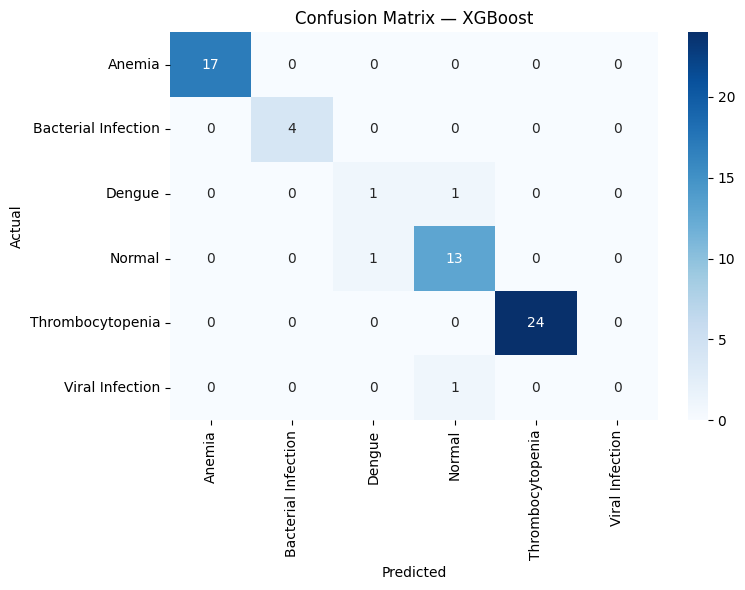

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — CONFUSION MATRIX                             ║
# ╚══════════════════════════════════════════════════════════╝

import seaborn as sns

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE
           Feature  Importance
9   PLATELET COUNT    0.256019
1      HAEMOGLOBIN    0.254651
2              TLC    0.119376
10           H.C.T    0.085444
0           GENDER    0.061868
13         M.C.H.C    0.042019
3        POLYMORPH    0.029669
8              RBC    0.028028
12           M.C.H    0.027393
4      LYMPHOCYTES    0.025963
11           M.C.V    0.024513
5      EOSINOPHILS    0.024464
6        MONOCYTES    0.020593
7        BASOPHILS    0.000000


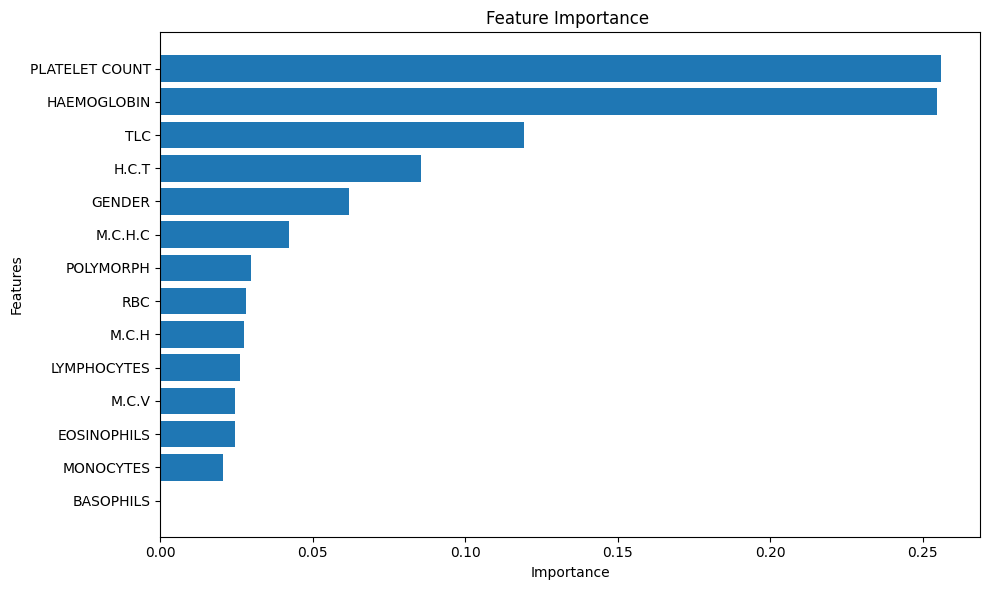

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 13 — FEATURE IMPORTANCE                           ║
# ╚══════════════════════════════════════════════════════════╝

print("\n=========================")
print("FEATURE IMPORTANCE")
print("=========================")

importance = best_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance ")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


SHAP EXPLAINABILITY


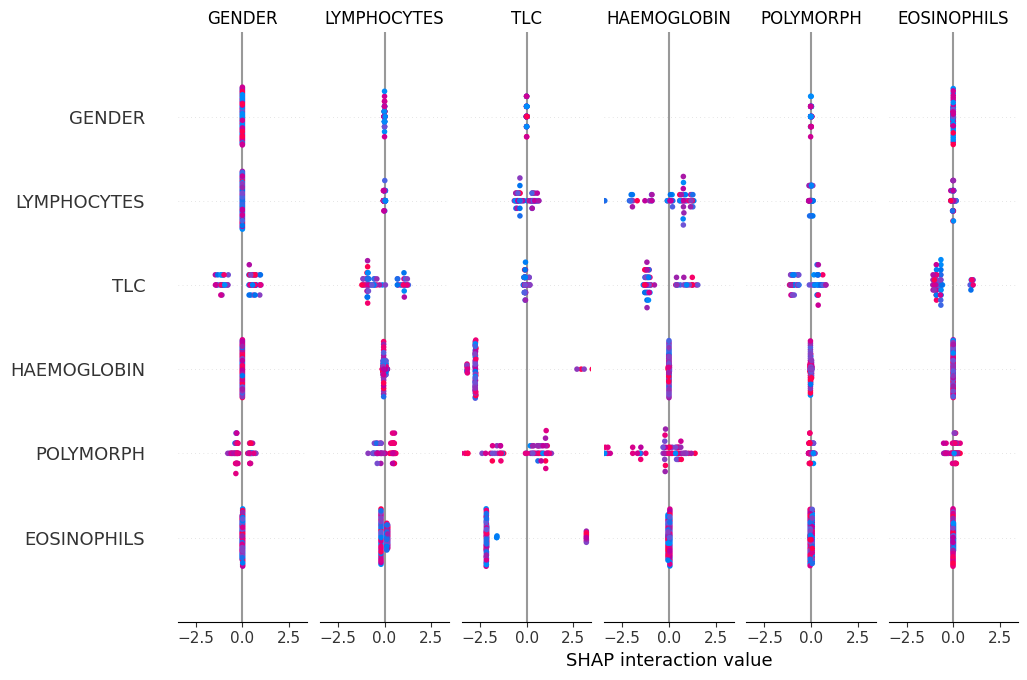

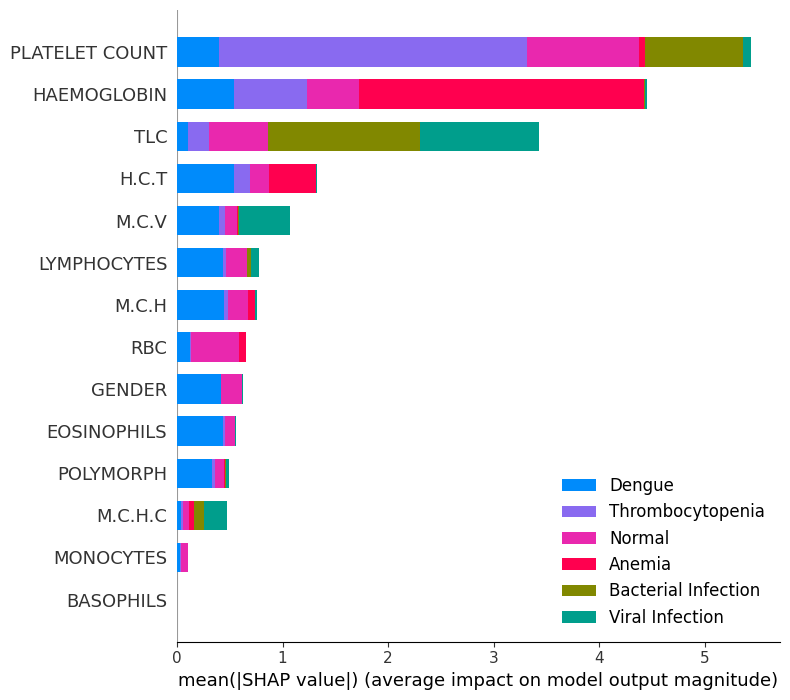

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 14 — SHAP EXPLAINABILITY                          ║
# ╚══════════════════════════════════════════════════════════╝

import shap

print("\n=========================")
print("SHAP EXPLAINABILITY")
print("=========================")

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, class_names=label_encoder.classes_)
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=label_encoder.classes_)

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 15 — SEVERITY LEVEL FUNCTION                      ║
# ╚══════════════════════════════════════════════════════════╝

def severity_level(disease):
    severity_map = {
        "Normal":               "Low",
        "Anemia":               "Moderate",
        "Viral Infection":      "Moderate",
        "Bacterial Infection":  "High",
        "Thrombocytopenia":     "High",
        "Dengue":               "Critical",
    }
    return severity_map.get(disease, "Unknown")

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 16 — FIXED classify_disease() FOR PREDICTION UI    ║
# ║                                                          ║
# ║                                                          ║
# ╚══════════════════════════════════════════════════════════╝

def classify_disease(hb, platelet, tlc, polymorph, lymphocytes,
                     eosinophils, monocytes, basophils, rbc,
                     hct, mcv, mch, mchc, ns1, gender=None):
    """
    Multi-parameter rule-based classifier for custom patient input.

    All six conditions are scored simultaneously across ALL CBC
    parameters. No single parameter alone can determine the result.

    Parameters:  All standard CBC values; ns1 = 'POSITIVE'/'NEGATIVE'
    Returns:     Predicted disease name (str)
    """

    scores = {
        "Anemia":               0,
        "Thrombocytopenia":     0,
        "Viral Infection":      0,
        "Bacterial Infection":  0,
        "Dengue":               0,
        "Normal":               0,
    }

    ns1_pos = str(ns1).strip().upper() == "POSITIVE"

    # ── NORMAL RANGE CHECKS ──────────────────────────────────────────
    hb_normal       = 12.0 <= hb <= 17.5
    platelet_normal = 1.5  <= platelet <= 4.5
    tlc_normal      = 4000 <= tlc <= 11000
    poly_normal     = 40   <= polymorph <= 75
    rbc_normal      = 3.5  <= rbc <= 5.5

    # ── ANEMIA ───────────────────────────────────────────────────────
    # Driven by: Hb (primary), RBC (secondary), HCT (secondary)
    if hb < 8.0:
        scores["Anemia"] += 7      # critically low
    elif hb < 10.0:
        scores["Anemia"] += 5
    elif hb < 12.0:
        scores["Anemia"] += 3

    if rbc < 3.0:
        scores["Anemia"] += 4      # very low RBC strongly supports anemia
    elif rbc < 3.5:
        scores["Anemia"] += 2

    if hct < 35:
        scores["Anemia"] += 2      # low haematocrit

    # MCH/MCV abnormality adds to anemia signal
    if mcv < 70 or mch < 22:
        scores["Anemia"] += 1      # microcytic anemia pattern

    # ── DENGUE ───────────────────────────────────────────────────────
    # Driven by: NS1 (mandatory trigger), platelet, TLC, Hb (near-normal)
    # Dengue almost never causes critically low Hb — that's Anemia
    if ns1_pos:
        scores["Dengue"] += 5      # NS1 positive is the key marker
        if platelet < 2.0:
            scores["Dengue"] += 3  # thrombocytopenia in dengue context
        if platelet < 1.0:
            scores["Dengue"] += 2  # more severe thrombocytopenia
        if tlc < 10000:
            scores["Dengue"] += 1  # normal/low WBC common in dengue
        if hb >= 11.0:
            scores["Dengue"] += 2  # dengue preserves Hb (unlike anemia)
    # If NS1 negative, dengue is very unlikely regardless of platelets
    # (no bonus added → other conditions will score higher)

    # ── THROMBOCYTOPENIA ─────────────────────────────────────────────
    # Driven by: very low platelets + NS1 negative (not dengue)
    if platelet < 0.5:
        scores["Thrombocytopenia"] += 7
    elif platelet < 1.0:
        scores["Thrombocytopenia"] += 5
    elif platelet < 1.5:
        scores["Thrombocytopenia"] += 3

    if not ns1_pos and platelet < 1.5:
        scores["Thrombocytopenia"] += 3   # NS1 neg → more likely pure Thrombocytopenia

    # Thrombocytopenia usually has near-normal Hb
    if hb >= 10.0:
        scores["Thrombocytopenia"] += 1

    # ── BACTERIAL INFECTION ──────────────────────────────────────────
    # Driven by: high TLC + high polymorph (neutrophilia)
    if tlc > 15000:
        scores["Bacterial Infection"] += 6
    elif tlc > 11000:
        scores["Bacterial Infection"] += 4

    if polymorph > 85:
        scores["Bacterial Infection"] += 4
    elif polymorph > 75:
        scores["Bacterial Infection"] += 2

    if tlc > 11000 and polymorph > 75:
        scores["Bacterial Infection"] += 2  # combo bonus

    # ── VIRAL INFECTION ──────────────────────────────────────────────
    # Driven by: low TLC + low polymorph / high lymphocytes
    if tlc < 3000:
        scores["Viral Infection"] += 5
    elif tlc < 4500:
        scores["Viral Infection"] += 3

    if polymorph < 45 and lymphocytes > 45:
        scores["Viral Infection"] += 4     # lymphocytosis pattern
    elif polymorph < 55 and lymphocytes > 35:
        scores["Viral Infection"] += 2

    if platelet >= 1.5:
        scores["Viral Infection"] += 1     # platelets usually normal in viral

    # ── NORMAL ───────────────────────────────────────────────────────
    if hb_normal and platelet_normal and tlc_normal and poly_normal:
        scores["Normal"] += 8              # all key params in range
    # Partial credit for each parameter in range
    if hb_normal:       scores["Normal"] += 1
    if platelet_normal: scores["Normal"] += 1
    if tlc_normal:      scores["Normal"] += 1
    if poly_normal:     scores["Normal"] += 1
    if rbc_normal:      scores["Normal"] += 1

    # ── CRITICAL GUARD: prevent a single high-score condition from   ──
    # ── masking a dangerously low Hb when RBC is also very low      ──
    if hb < 8.0 and rbc < 3.0:
        # Both indicators of severe anemia — Anemia must be the winner
        scores["Anemia"] = max(scores["Anemia"], max(scores.values()) + 1)

    return max(scores, key=scores.get)

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 17 — SAVE MODEL                                   ║
# ╚══════════════════════════════════════════════════════════╝

joblib.dump(best_model,    'cbc_disease_model.pkl')
joblib.dump(label_encoder, 'cbc_label_encoder.pkl')

print("Model and encoder saved successfully.")

Model and encoder saved successfully.


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 18 — CUSTOM PATIENT PREDICTION (FIXED)             ║
# ║                                                          ║
# ║                                                          ║
# ╚══════════════════════════════════════════════════════════╝

print("\n=========================")
print("CUSTOM PATIENT TEST")
print("=========================")

# ── Enter patient CBC values here ──────────────────────────
patient = {
    'GENDER':        1,      # 0 = Female, 1 = Male
    'HAEMOGLOBIN':   14,     # g/dL
    'TLC':           2500,   # cells/µL
    'POLYMORPH':     60.0,   # %
    'LYMPHOCYTES':   20,     # %
    'EOSINOPHILS':   5,      # %
    'MONOCYTES':     2.0,    # %
    'BASOPHILS':     0,      # %
    'RBC':           6.5,    # million/µL
    'PLATELET COUNT': 2.0,   # (×10⁵/µL as used in this dataset)
    'H.C.T':         35.0,   # %
    'M.C.V':         80.0,   # fL
    'M.C.H':         25.0,   # pg
    'M.C.H.C':       30.0,   # g/dL
}
ns1_test = 'NEGATIVE'       # 'POSITIVE' or 'NEGATIVE'
# ──────────────────────────────────────────────────────────

# ── ML Model Prediction ────────────────────────────────────
user_df = pd.DataFrame([patient])
ml_prediction_enc    = best_model.predict(user_df)[0]
ml_predicted_disease = label_encoder.inverse_transform([ml_prediction_enc])[0]
probabilities        = best_model.predict_proba(user_df)[0]

# ── Rule-based Prediction (with NS1 included) ──────────────
rule_predicted_disease = classify_disease(
    hb          = patient['HAEMOGLOBIN'],
    platelet    = patient['PLATELET COUNT'],
    tlc         = patient['TLC'],
    polymorph   = patient['POLYMORPH'],
    lymphocytes = patient['LYMPHOCYTES'],
    eosinophils = patient['EOSINOPHILS'],
    monocytes   = patient['MONOCYTES'],
    basophils   = patient['BASOPHILS'],
    rbc         = patient['RBC'],
    hct         = patient['H.C.T'],
    mcv         = patient['M.C.V'],
    mch         = patient['M.C.H'],
    mchc        = patient['M.C.H.C'],
    ns1         = ns1_test,
    gender      = patient['GENDER'],
)

# ── Final Decision: ML wins; rule-based used as safety net ─
# If ML and rules strongly disagree, flag it for clinician review
final_disease = ml_predicted_disease
if ml_predicted_disease != rule_predicted_disease:
    conflict_note = (f"⚠️  Note: ML model predicted '{ml_predicted_disease}' "
                     f"but rule-based check suggests '{rule_predicted_disease}'. "
                     f"Please review manually.")
else:
    conflict_note = "✅  ML and rule-based methods agree."

severity = severity_level(final_disease)

# ── Print Report ────────────────────────────────────────────
print("\nDisease Probabilities (ML Model):\n")
for disease, prob in zip(label_encoder.classes_, probabilities):
    bar = "█" * int(prob * 30)
    print(f"  {disease:<22} {prob*100:5.1f}%  {bar}")

print("\n=========================")
print("FINAL PATIENT REPORT")
print("=========================")
print(f"ML Predicted Disease  : {ml_predicted_disease}")
print(f"Rule-Based Check      : {rule_predicted_disease}")
print(f"NS1 Test Result       : {ns1_test}")
print(f"Severity Level        : {severity}")
print(f"\n{conflict_note}")



CUSTOM PATIENT TEST

Disease Probabilities (ML Model):

  Anemia                   6.3%  █
  Bacterial Infection      1.3%  
  Dengue                   0.6%  
  Normal                  48.2%  ██████████████
  Thrombocytopenia         2.9%  
  Viral Infection         40.6%  ████████████

FINAL PATIENT REPORT
ML Predicted Disease  : Normal
Rule-Based Check      : Viral Infection
NS1 Test Result       : NEGATIVE
Severity Level        : Low

⚠️  Note: ML model predicted 'Normal' but rule-based check suggests 'Viral Infection'. Please review manually.


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 19 — VERIFY THE ORIGINAL BUG IS FIXED              ║
# ║                                                          ║
# ╚══════════════════════════════════════════════════════════╝

print("\n=========================")
print("BUG VERIFICATION")
print("=========================")

test_cases = [
    {
        "desc":    "Low Hb=7, Low Platelets=0.9, NS1=NEGATIVE → expect Anemia",
        "params":  dict(hb=7,   platelet=0.9, tlc=7000, polymorph=60, lymphocytes=25,
                        eosinophils=3, monocytes=2, basophils=0, rbc=2.8,
                        hct=30, mcv=75, mch=23, mchc=30, ns1='NEGATIVE'),
        "expect":  "Anemia"
    },
    {
        "desc":    "NS1=POSITIVE, Low Platelets=0.9, Normal Hb=13 → expect Dengue",
        "params":  dict(hb=13,  platelet=0.9, tlc=7000, polymorph=60, lymphocytes=25,
                        eosinophils=3, monocytes=2, basophils=0, rbc=4.5,
                        hct=40, mcv=82, mch=27, mchc=32, ns1='POSITIVE'),
        "expect":  "Dengue"
    },
    {
        "desc":    "Very Low Platelets=0.3, NS1=NEGATIVE, Normal Hb=14 → expect Thrombocytopenia",
        "params":  dict(hb=14,  platelet=0.3, tlc=5000, polymorph=55, lymphocytes=30,
                        eosinophils=3, monocytes=2, basophils=0, rbc=4.8,
                        hct=42, mcv=85, mch=28, mchc=33, ns1='NEGATIVE'),
        "expect":  "Thrombocytopenia"
    },
    {
        "desc":    "High TLC=14000, High Polymorph=82% → expect Bacterial Infection",
        "params":  dict(hb=12,  platelet=3.0, tlc=14000, polymorph=82, lymphocytes=12,
                        eosinophils=2, monocytes=3, basophils=0, rbc=4.2,
                        hct=38, mcv=82, mch=27, mchc=32, ns1='NEGATIVE'),
        "expect":  "Bacterial Infection"
    },
    {
        "desc":    "Low TLC=2500, High Lymph=55%, Low Poly=35% → expect Viral Infection",
        "params":  dict(hb=11.5, platelet=2.0, tlc=2500, polymorph=35, lymphocytes=55,
                        eosinophils=3, monocytes=2, basophils=0, rbc=4.0,
                        hct=36, mcv=80, mch=26, mchc=31, ns1='NEGATIVE'),
        "expect":  "Viral Infection"
    },
    {
        "desc":    "All Normal CBC → expect Normal",
        "params":  dict(hb=14,  platelet=2.5, tlc=7000, polymorph=60, lymphocytes=25,
                        eosinophils=3, monocytes=2, basophils=0, rbc=4.5,
                        hct=42, mcv=83, mch=28, mchc=33, ns1='NEGATIVE'),
        "expect":  "Normal"
    },
]

all_pass = True
for case in test_cases:
    result = classify_disease(**case["params"])
    status = "✅ PASS" if result == case["expect"] else "❌ FAIL"
    if result != case["expect"]:
        all_pass = False
    print(f"\n{status}")
    print(f"  Test   : {case['desc']}")
    print(f"  Got    : {result}   |   Expected: {case['expect']}")

print("\n" + ("✅ ALL TESTS PASSED" if all_pass else "⚠️  SOME TESTS FAILED — review classify_disease()"))


BUG VERIFICATION

✅ PASS
  Test   : Low Hb=7, Low Platelets=0.9, NS1=NEGATIVE → expect Anemia
  Got    : Anemia   |   Expected: Anemia

✅ PASS
  Test   : NS1=POSITIVE, Low Platelets=0.9, Normal Hb=13 → expect Dengue
  Got    : Dengue   |   Expected: Dengue

✅ PASS
  Test   : Very Low Platelets=0.3, NS1=NEGATIVE, Normal Hb=14 → expect Thrombocytopenia
  Got    : Thrombocytopenia   |   Expected: Thrombocytopenia

✅ PASS
  Test   : High TLC=14000, High Polymorph=82% → expect Bacterial Infection
  Got    : Bacterial Infection   |   Expected: Bacterial Infection

✅ PASS
  Test   : Low TLC=2500, High Lymph=55%, Low Poly=35% → expect Viral Infection
  Got    : Viral Infection   |   Expected: Viral Infection

✅ PASS
  Test   : All Normal CBC → expect Normal
  Got    : Normal   |   Expected: Normal

✅ ALL TESTS PASSED
